# Practicum 2: Regressie Analyse Bike Sharing

In dit notebook ontwikkelen en evalueren we een regressiemodel om het aantal verhuurde deelfietsen te voorspellen. We gebruiken de **Bike Sharing Dataset** (UCI Machine Learning Repository).

### Stap 1: Dataset Selectie & Verantwoording

**Wat wordt er voorspeld?**
De doelvariabele (target) is `cnt`: het totale aantal verhuurde fietsen gedurende een specifiek uur. 

**Waarom is deze dataset geschikt voor regressie?**
Regressie is bedoeld om een continue, numerieke waarde te voorspellen. Aangezien `cnt` een telling is (variërend van 1 tot bijna 1000 per uur), is dit een geschikte continue afhankelijke variabele. 
Daarnaast voldoet de dataset aan de eisen:
- **Rijen:** Het bestand `hour.csv` bevat 17.379 records (eis: >3000).
- **Variabelen:** We gebruiken 12 onafhankelijke variabelen (eis: >10).
- **Bron:** Geen Kaggle, maar de officiële UCI repository. ([Link naar dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset))

### Data Dictionary
Hieronder volgt een overzicht van de variabelen die we in dit regressiemodel gebruiken, nadat we de niet-relevante ID- en datumkolommen hebben verwijderd:

| Variabele | Datatype | Soort variabele | Toelichting |
|---|---|---|---|
| season | Integer | Categorisch (Ordinaal) | Seizoen (1: Lente, 2: Zomer, 3: Herfst, 4: Winter) |
| yr | Integer | Categorisch (Binair) | Jaar (0: 2011, 1: 2012) |
| mnth | Integer | Categorisch (Nominaal) | Maand (1 t/m 12) |
| hr | Integer | Categorisch (Nominaal) | Uur van de dag (0 t/m 23) |
| holiday | Integer | Categorisch (Binair) | Is het een feestdag? (0: Nee, 1: Ja) |
| weekday | Integer | Categorisch (Nominaal) | Dag van de week (0: Zondag t/m 6: Zaterdag) |
| workingday | Integer | Categorisch (Binair) | Is het een werkdag? (0: Nee, 1: Ja) |
| weathersit | Integer | Categorisch (Ordinaal) | Weersituatie (1: Helder, 2: Bewolkt, 3: Lichte regen, 4: Zware regen/sneeuw) |
| temp | Float | Numeriek (Continue) | Genormaliseerde temperatuur in Celsius. |
| atemp | Float | Numeriek (Continue) | Genormaliseerde gevoelstemperatuur. |
| hum | Float | Numeriek (Continue) | Genormaliseerde luchtvochtigheid. |
| windspeed | Float | Numeriek (Continue) | Genormaliseerde windsnelheid. |
| **cnt** | **Integer** | **Numeriek (Continue)** | **Target: Totaal aantal verhuurde fietsen.** |

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle 

df = pd.read_csv('../csv/hour.csv')
display(df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Stap 2: Exploratory Data Analysis (EDA) & Preprocessing

**Verantwoording van de Scope (Feature Selectie vooraf)**
Voordat we de data analyseren, maken we een bewuste keuze in welke variabelen we behouden en welke we verwijderen, om data leakage en ruis te voorkomen:
1. `instant`: Dit is enkel een rij-index en bevat geen voorspellende waarde.
2. `dteday`: De specifieke datum-string. Omdat we de datum al hebben opgedeeld in losse numerieke features (`yr`, `mnth`, `weekday`), is deze kolom overbodig.
3. `casual` en `registered`: Onze doelvariabele `cnt` is exact de som van deze twee kolommen. Als we deze behouden, leert het model simpelweg een optelsom te maken (data leakage) in plaats van te voorspellen op basis van externe factoren zoals het weer.

Deze vier kolommen verwijderen we. De overige 12 variabelen (zoals temperatuur, weertype, en uur) vormen de scope van ons onderzoek.

In [6]:
# Verwijderen van irrelevante en data leaking features
kolommen_te_verwijderen = ['instant', 'dteday', 'casual', 'registered']
df = df.drop(columns=kolommen_te_verwijderen)

# check op missing features
print(f"Totaal aantal missende waarden: {df.isnull().sum().sum()}")

Totaal aantal missende waarden: 0


**Analyse van de Doelvariabele (`cnt`)**
We bekijken de verdeling van onze target visueel met een histogram. Om te voorkomen dat we conclusies trekken op basis van uitsluitend visuele observaties, valideren we dit direct met twee statistische tests: de *Skewness* (scheefheid) en *D'Agostino's K-squared test* voor normaliteit.

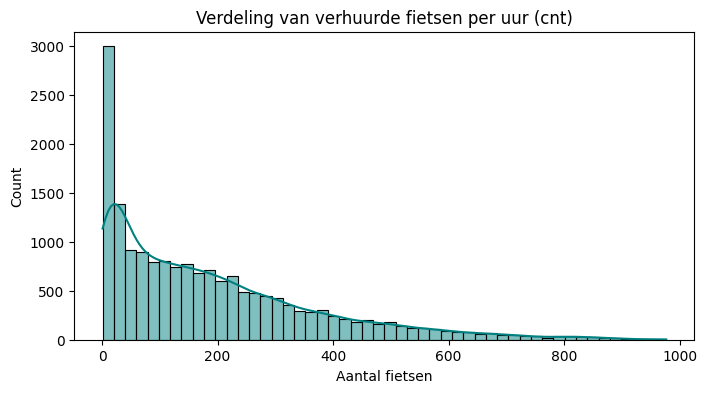

Statistische validatie van de verdeling:
- Skewness: 1.28 (Waarden ver boven de 0 duiden op sterke rechts-scheefheid)
- Normaltest p-waarde: 0.00000


In [7]:
# visuele analyse 
plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], bins=50, kde=True, color='teal')
plt.title('Verdeling van verhuurde fietsen per uur (cnt)')
plt.xlabel('Aantal fietsen')
plt.show()

# statisctische validatie
skewness = df['cnt'].skew()
k2_stat, p_val = stats.normaltest(df['cnt'])

print(f"Statistische validatie van de verdeling:")
print(f"- Skewness: {skewness:.2f} (Waarden ver boven de 0 duiden op sterke rechts-scheefheid)")
print(f"- Normaltest p-waarde: {p_val:.5f}")

*Conclusie EDA:* Visueel zien we een sterke piek aan de linkerkant. De statistiek bevestigt dit: de Skewness is 1.28 (sterk rechts-scheef) en de p-waarde van de normaltest is kleiner dan 0.05. We verwerpen de nulhypothese; de target is **niet normaal verdeeld**. We hoeven hier echter geen actie op te ondernemen, omdat robuuste regressiemodellen (zoals Random Forest) goed met niet-normale verdelingen om kunnen gaan.

### Feature Selection: Pairwise Regression

We onderzoeken de voorspellende kracht van de overgebleven variabelen afzonderlijk met *Pairwise Regression*. We bereken niet alleen hoeveel variantie elke feature verklaart ($R^2$), maar we voegen ook de **p-waarde** (Pearson) toe. Hiermee toetsen we of de afhankelijkheid statistisch significant is, zodat we geen features gebruiken die op toeval berusten.

In [8]:
features = df.drop(columns=['cnt']).columns
pairwise_results = []

for feature in features:
    # berekenen van de Pearson correlatie en p-waarde
    r, p_waarde = stats.pearsonr(df[feature], df['cnt'])
    
    # R2 is de correlatie in het kwadraat
    r2 = r**2
    
    pairwise_results.append({
        "Feature": feature, 
        "R2_Score": r2, 
        "P-waarde": p_waarde,
        "Significant?": "Ja" if p_waarde < 0.05 else "Nee"
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values(by='R2_Score', ascending=False)
display(pairwise_df)

,Feature,R2_Score,P-waarde,Significant?
8,temp,0.163841,0.000000e+00,Ja
9,atemp,0.160744,0.000000e+00,Ja
3,hr,0.155292,0.000000e+00,Ja
10,hum,0.104271,0.000000e+00,Ja
1,yr,0.062748,7.213184e-247,Ja
0,season,0.031704,9.182191e-124,Ja
7,weathersit,0.020285,1.979754e-79,Ja
2,mnth,0.014553,2.397022e-57,Ja
11,windspeed,0.008693,7.345742e-35,Ja
4,holiday,0.000956,4.546169e-05,Ja


*Conclusie Feature Selection:* Uit de statistische test blijkt dat elke feature een p-waarde < 0.05 heeft, wat betekent dat ze allemaal statistisch significant zijn en we geen enkele feature hoeven te verwijderen wegens gebrek aan relevantie. Individueel verklaren `temp` en `hr` de meeste variantie ($R^2$), maar de lage R2-scores (maximaal 0.16) bewijzen dat een lineair model op basis van één variabele onvoldoende is. We zullen alle features combineren in complexere modellen.

### Train/Test Split & Modeltraining

We splitsen de data (80% train, 20% test) en trainen drie modellen om de prestaties te vergelijken.

In [9]:
X = df.drop(columns=['cnt'])
y = df['cnt']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

# modellen trainen en evalueren
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    results.append({"Model": name, "R2 Score": r2, "RMSE": rmse})

eval_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(eval_df)

,Model,R2 Score,RMSE
2,Random Forest,0.944108,42.069424
1,Decision Tree,0.892851,58.248634
0,Linear Regression,0.387981,139.211452


### Model Keuze & Evaluatie

Op basis van de resultaten kies ik de **Random Forest Regressor** als het definitieve model. 
* Linear Regression presteert matig ($R^2$ rond de 0.39). Dit komt doordat relaties in deze data niet strikt lineair zijn (het uur van de dag heeft bijvoorbeeld een golfbeweging rond de spitsuren). 
* Random Forest kan deze niet-lineaire interacties veel beter oppakken en behaalt veruit de hoogste $R^2$ (ca. 0.94) en de laagste RMSE.

### Stap 3: Model Retrain & Opslaan

Nu we bewezen hebben dat Random Forest het beste presteert, trainen we dit model opnieuw op de **volledige dataset** (X en y). Hierdoor heeft het model de maximale hoeveelheid historische data gezien voordat we het inzetten in de applicatie (productie). Daarna slaan we het op via `pickle`.

In [10]:
# retrinen op volledige data
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X, y)

# model opslaan als augurk
with open('bike_rf_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

print("Model succesvol getraind en opgeslagen als 'bike_rf_model.pkl'. Klaar voor de webapplicatie!")

Model succesvol getraind en opgeslagen als 'bike_rf_model.pkl'. Klaar voor de webapplicatie!
